In [468]:
import yfinance as yf
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

ticker = yf.Ticker("AAPL")
df = ticker.history(period="7y", interval="1d")

df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

In [469]:
df

,Open,High,Low,Close,Volume
Date,,,,,
2019-06-24 00:00:00-04:00,47.491216,47.878726,47.402712,47.500786,72881600
2019-06-25 00:00:00-04:00,47.464892,47.663430,46.713797,46.780777,84281200
2019-06-26 00:00:00-04:00,47.307019,48.077250,47.206554,47.792599,104270000
2019-06-27 00:00:00-04:00,47.909814,48.215996,47.737592,47.778255,83598800
2019-06-28 00:00:00-04:00,47.524692,47.720839,47.134795,47.342899,124442400
...,...,...,...,...,...
2026-06-16 00:00:00-04:00,295.250000,300.480011,293.970001,299.239990,39874400
2026-06-17 00:00:00-04:00,300.850006,302.070007,294.359985,295.950012,42745100
2026-06-18 00:00:00-04:00,298.109985,300.570007,295.619995,298.010010,85962200


In [470]:
# ---------------------------------------------------------
# 1. VWAP (Volume Weighted Average Price)
# The Institutional Benchmark. Must reset monthly.
# ---------------------------------------------------------

# 2. Calculate the Typical Price and Price-Volume (PV)
df['Typical_Price'] = (df['High'] + df['Low'] + df['Close']) / 3
df['PV'] = df['Typical_Price'] * df['Volume']

# 3. Create Year and Month columns to act as our "Anchor"
df['Year'] = df.index.year
df['Month'] = df.index.month

# 4. The Monthly Anchor: Group by Year AND Month to reset the sum on the 1st
df['Cumulative_PV'] = df.groupby(['Year', 'Month'])['PV'].cumsum()
df['Cumulative_Vol'] = df.groupby(['Year', 'Month'])['Volume'].cumsum()

# 5. Calculate the final Monthly VWAP
df['Monthly_VWAP'] = df['Cumulative_PV'] / df['Cumulative_Vol']

# Clean up temporary columns
df = df.drop(columns=['Typical_Price', 'PV', 'Cumulative_PV', 'Cumulative_Vol', 'Year', 'Month'])

# ---------------------------------------------------------
# 2. RSI (Relative Strength Index)
# The Momentum Spring Coil. (Standard 14-period)
# ---------------------------------------------------------
# Find the difference in closing price from the previous 5-day
delta = df['Close'].diff()

# Separate the positive gains from the negative losses
gain = delta.clip(lower=0)
loss = -1 * delta.clip(upper=0)

# Calculate the Exponential Moving Average (EMA) of gains and losses
avg_gain = gain.ewm(com=14 - 1, adjust=False).mean()
avg_loss = loss.ewm(com=14 - 1, adjust=False).mean()

# Calculate the Relative Strength (RS)
rs = avg_gain / avg_loss

# Convert into an oscillator that bounces between 0 and 100
df['RSI'] = 100 - (100 / (1 + rs))

# ---------------------------------------------------------
# 3. ATR (Average True Range)
# The Volatility Risk Manager. (Standard 14-period)
# ---------------------------------------------------------
df['Prev_Close'] = df['Close'].shift(1)

# True Range is the MAXIMUM of these three volatility measures
df['TR1'] = df['High'] - df['Low'] # Current candle range
df['TR2'] = (df['High'] - df['Prev_Close']).abs() # Gap up from last close
df['TR3'] = (df['Low'] - df['Prev_Close']).abs()  # Gap down from last close

# Find the max value across the columns for each row
df['True_Range'] = df[['TR1', 'TR2', 'TR3']].max(axis=1)

# Smooth it out with a 14-period rolling mean
df['ATR'] = df['True_Range'].rolling(window=14).mean()

# ---------------------------------------------------------
# 4. Clean Up
# ---------------------------------------------------------
# Drop the intermediate columns we used for math so the dataframe is clean
columns_to_drop = ['Prev_Close', 'TR1', 'TR2', 'TR3', 'True_Range']
df = df.drop(columns=columns_to_drop)

# Drop early rows that have NaNs due to rolling windows
df = df.dropna()

df

,Open,High,Low,Close,Volume,Monthly_VWAP,RSI,ATR
Date,,,,,,,,
2019-07-12 00:00:00-04:00,48.426487,48.797251,48.366686,48.629810,70380800,48.367287,30.175904,0.756561
2019-07-15 00:00:00-04:00,48.818784,49.244564,48.797256,49.086693,67789600,48.427115,34.295227,0.766471
2019-07-16 00:00:00-04:00,48.938378,49.301967,48.677649,48.916851,67467200,48.470724,33.503927,0.743234
2019-07-17 00:00:00-04:00,48.809206,49.057975,48.622629,48.641766,56430000,48.489974,32.207718,0.681725
2019-07-18 00:00:00-04:00,48.797263,49.246965,48.725502,49.194340,74162400,48.533511,37.443253,0.690782
...,...,...,...,...,...,...,...,...
2026-06-16 00:00:00-04:00,295.250000,300.480011,293.970001,299.239990,39874400,302.286588,52.160660,7.880718
2026-06-17 00:00:00-04:00,300.850006,302.070007,294.359985,295.950012,42745100,301.976305,48.923303,8.200721
2026-06-18 00:00:00-04:00,298.109985,300.570007,295.619995,298.010010,85962200,301.528723,50.975047,8.163579


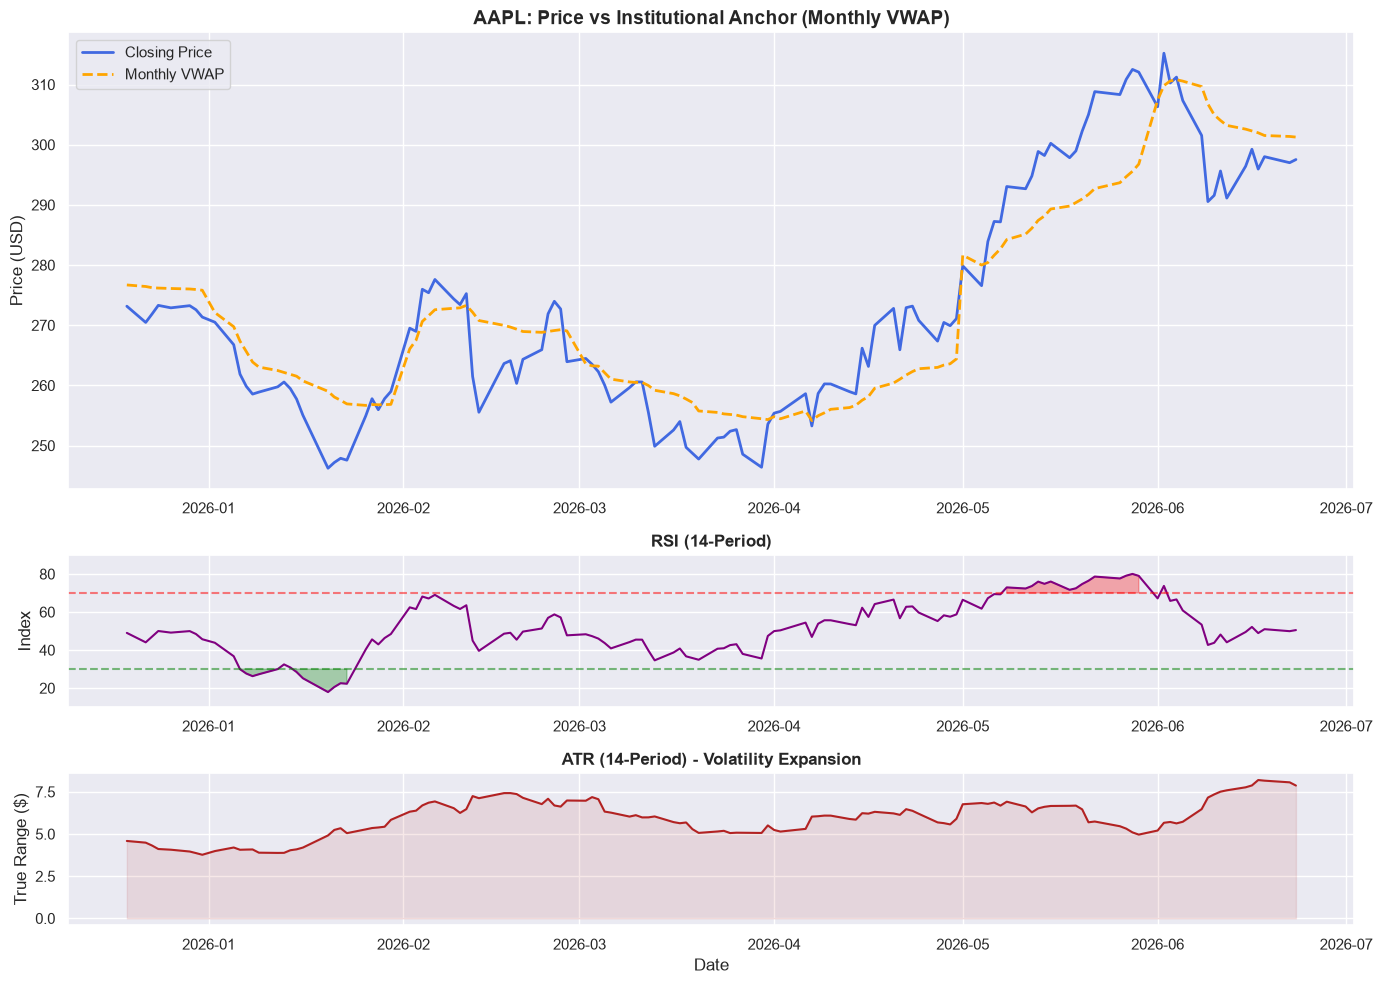

In [471]:
plot_df = df.tail(126)

# Set a clean, professional financial theme
sns.set_theme(style="darkgrid")

# Create a figure with 3 vertically stacked subplots
# height_ratios makes the Price chart larger than the indicators below it
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1, 1]})

# ---------------------------------------------------------
# Top Chart: Price and Monthly VWAP
# ---------------------------------------------------------
ax1.plot(plot_df.index, plot_df['Close'], label='Closing Price', color='royalblue', linewidth=2)
ax1.plot(plot_df.index, plot_df['Monthly_VWAP'], label='Monthly VWAP', color='orange', linestyle='--', linewidth=2)

ax1.set_title("AAPL: Price vs Institutional Anchor (Monthly VWAP)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Price (USD)")
ax1.legend(loc='upper left')

# ---------------------------------------------------------
# Middle Chart: RSI (The Momentum Spring)
# ---------------------------------------------------------
ax2.plot(plot_df.index, plot_df['RSI'], color='purple', linewidth=1.5)

# Draw the Overbought (70) and Oversold (30) boundary lines
ax2.axhline(70, color='red', linestyle='--', alpha=0.5)
ax2.axhline(30, color='green', linestyle='--', alpha=0.5)

# Fill the extreme zones so they visually pop out to you
ax2.fill_between(plot_df.index, plot_df['RSI'], 70, where=(plot_df['RSI'] >= 70), color='red', alpha=0.3)
ax2.fill_between(plot_df.index, plot_df['RSI'], 30, where=(plot_df['RSI'] <= 30), color='green', alpha=0.3)

ax2.set_title("RSI (14-Period)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Index")
ax2.set_ylim(10, 90)

# ---------------------------------------------------------
# Bottom Chart: ATR (The Volatility Engine)
# ---------------------------------------------------------
ax3.plot(plot_df.index, plot_df['ATR'], color='firebrick', linewidth=1.5)

# Fill under the ATR line to show volatility "swells"
ax3.fill_between(plot_df.index, plot_df['ATR'], 0, color='firebrick', alpha=0.1)

ax3.set_title("ATR (14-Period) - Volatility Expansion", fontsize=12, fontweight='bold')
ax3.set_ylabel("True Range ($)")
ax3.set_xlabel("Date")

# Clean up layout so labels don't overlap
plt.tight_layout()
plt.show()

In [472]:
# ---------------------------------------------------------
# Fetch Data & Calculate Indicators
# ---------------------------------------------------------

# Calculate the 21-Day Simple Moving Average (The Trend)
df['SMA_21'] = df['Close'].rolling(window=21).mean()
df['SMA_42'] = df['Close'].rolling(window=42).mean()
df['SMA_63'] = df['Close'].rolling(window=63).mean()


# Calculate the Standard Deviation (The Volatility)
df['Std_Dev'] = df['Close'].rolling(window=21).std()

# Calculate Bollinger Bands (2 Standard Deviations up and down)
df['Upper_Band'] = df['SMA_21'] + (df['Std_Dev'] * 2)
df['Lower_Band'] = df['SMA_21'] - (df['Std_Dev'] * 2)

df = df.dropna()
df

,Open,High,Low,Close,Volume,Monthly_VWAP,RSI,ATR,SMA_21,SMA_42,SMA_63,Std_Dev,Upper_Band,Lower_Band
Date,,,,,,,,,,,,,,
2019-10-09 00:00:00-04:00,54.512421,54.694904,54.178666,54.512421,74770400,53.856586,60.897349,1.083932,53.252859,51.638684,50.762214,0.734642,54.722143,51.783575
2019-10-10 00:00:00-04:00,54.728510,55.331191,54.577242,55.247150,113013600,53.998407,64.134057,1.055118,53.327179,51.807962,50.867251,0.850506,55.028191,51.626167
2019-10-11 00:00:00-04:00,55.933868,57.059990,55.780198,56.716633,166795600,54.374017,69.560934,1.147046,53.477191,51.963691,50.988362,1.127515,55.732222,51.222161
2019-10-14 00:00:00-04:00,56.402090,57.177652,56.346866,56.634998,96427600,54.560082,68.936893,1.115489,53.672939,52.153036,51.110872,1.297784,56.268508,51.077370
2019-10-15 00:00:00-04:00,56.759850,57.062389,56.397284,56.502934,87360000,54.700476,67.876022,1.088219,53.849249,52.345011,51.235652,1.419149,56.687547,51.010950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-16 00:00:00-04:00,295.250000,300.480011,293.970001,299.239990,39874400,302.286588,52.160660,7.880718,303.478572,292.146306,279.708006,7.675541,318.829654,288.127491
2026-06-17 00:00:00-04:00,300.850006,302.070007,294.359985,295.950012,42745100,301.976305,48.923303,8.200721,303.388573,292.764610,280.441976,7.755624,318.899821,287.877325
2026-06-18 00:00:00-04:00,298.109985,300.570007,295.619995,298.010010,85962200,301.528723,50.975047,8.163579,303.342859,293.364881,281.224185,7.785741,318.914342,287.771377


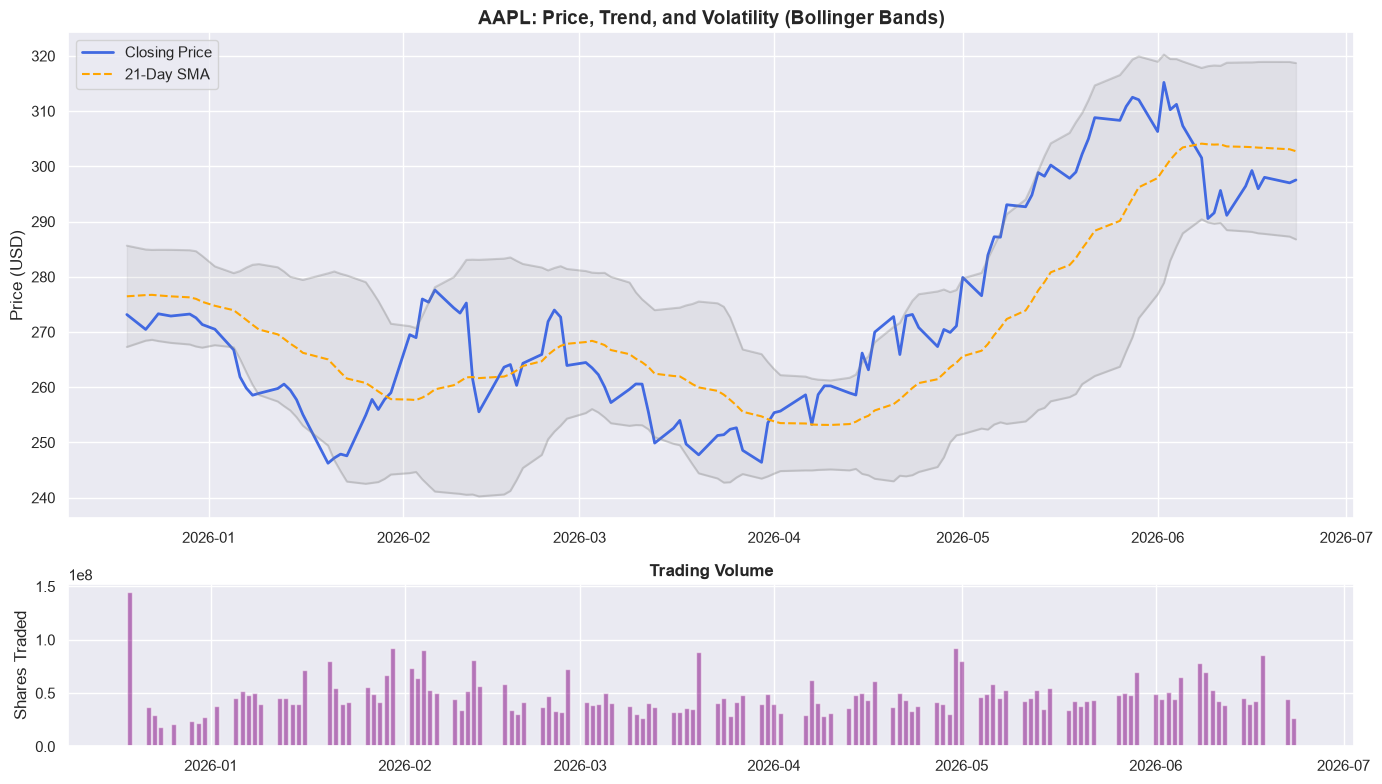

In [473]:
plot_df = df.tail(126)

# ---------------------------------------------------------
# 1. Visualization Setup
# ---------------------------------------------------------
# Apply Seaborn's dark theme for a clean, analytical look
sns.set_theme(style="darkgrid")

# Create a figure with 2 subplots (Price on top, Volume on bottom)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# ---------------------------------------------------------
# 2. Top Chart: Price and Bollinger Bands
# ---------------------------------------------------------
sns.lineplot(data=plot_df, x=plot_df.index, y='Close', label='Closing Price', color='royalblue', linewidth=2, ax=ax1)
sns.lineplot(data=plot_df, x=plot_df.index, y='SMA_21', label='21-Day SMA', color='orange', linestyle='--', ax=ax1)

# Plot the invisible boundary lines for the bands
sns.lineplot(data=plot_df, x=plot_df.index, y='Upper_Band', color='gray', alpha=0.3, ax=ax1)
sns.lineplot(data=plot_df, x=plot_df.index, y='Lower_Band', color='gray', alpha=0.3, ax=ax1)

# Fill the "volatility envelope" between the upper and lower bands
ax1.fill_between(plot_df.index, plot_df['Lower_Band'], plot_df['Upper_Band'], color='gray', alpha=0.1)

ax1.set_title("AAPL: Price, Trend, and Volatility (Bollinger Bands)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Price (USD)")
ax1.set_xlabel("") # Hide x-label to keep it clean

# ---------------------------------------------------------
# 3. Bottom Chart: Volume
# ---------------------------------------------------------
# Matplotlib handles datetime bar charts a bit cleaner than Seaborn here
ax2.bar(plot_df.index, plot_df['Volume'], color='purple', alpha=0.5)
ax2.set_title("Trading Volume", fontsize=12, fontweight='bold')
ax2.set_ylabel("Shares Traded")

# Clean up layout and display
plt.tight_layout()
plt.show()

In [474]:
# ---------------------------------------------------------
# 1. The Loop: 14-Day Micro Context
# ---------------------------------------------------------
# This dynamically creates Close_Lag_1 all the way to Close_Lag_14
for i in range(1, 15):
    df[f'Close_Lag_{i}'] = df['Close'].shift(i)

# ---------------------------------------------------------
# 2. The Regressor Target: Exact Future Price
# ---------------------------------------------------------
# Shift the close price UP by 1 to get tomorrow's exact dollar amount
df['Target_close'] = df['Close'].shift(-1)

df['Daily_Return'] = df['Close'].pct_change()
# ---------------------------------------------------------
# 3. The Purge
# ---------------------------------------------------------
# Drop all the rows with NaNs created by the shifting
df = df.dropna()
df

C:\Users\rites\AppData\Local\Temp\ipykernel_12568\3742282660.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'Close_Lag_{i}'] = df['Close'].shift(i)
C:\Users\rites\AppData\Local\Temp\ipykernel_12568\3742282660.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'Close_Lag_{i}'] = df['Close'].shift(i)
C:\Users\rites\AppData\Local\Temp\ipykernel_12568\3742282660.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

,Open,High,Low,Close,Volume,Monthly_VWAP,RSI,ATR,SMA_21,SMA_42,...,Close_Lag_7,Close_Lag_8,Close_Lag_9,Close_Lag_10,Close_Lag_11,Close_Lag_12,Close_Lag_13,Close_Lag_14,Target_close,Daily_Return
Date,,,,,,,,,,,,,,,,,,,,,
2019-10-29 00:00:00-04:00,59.780455,59.967741,58.243746,58.416622,142839600,56.006906,65.489524,0.898016,56.249675,54.243432,...,56.764656,56.493328,56.274830,56.502934,56.634998,56.716633,55.247150,54.512421,58.409409,-0.023128
2019-10-30 00:00:00-04:00,58.769575,58.899237,57.917184,58.409409,124522000,56.137272,65.429145,0.909679,56.463145,54.440781,...,57.749119,56.764656,56.493328,56.274830,56.502934,56.634998,56.716633,55.247150,59.730030,-0.000123
2019-10-31 00:00:00-04:00,59.365064,59.828476,56.968753,59.730030,139162000,56.291987,70.746577,0.984456,56.803874,54.686952,...,57.617050,57.749119,56.764656,56.493328,56.274830,56.502934,56.634998,56.716633,61.425220,0.022610
2019-11-01 00:00:00-04:00,59.917319,61.451629,59.826080,61.425220,151125200,60.900976,75.875975,1.048086,57.204059,54.953532,...,58.390209,57.617050,57.749119,56.764656,56.493328,56.274830,56.502934,56.634998,61.828602,0.028381
2019-11-04 00:00:00-05:00,61.787780,61.912642,61.319568,61.828602,103272000,61.220036,76.913343,1.042941,57.552678,55.206335,...,58.486263,58.390209,57.617050,57.749119,56.764656,56.493328,56.274830,56.502934,61.739754,0.006567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-15 00:00:00-04:00,294.119995,297.779999,291.700012,296.420013,45732600,302.587199,49.501004,7.770004,303.525716,291.287200,...,311.230011,310.260010,315.200012,306.309998,312.059998,312.510010,310.850006,308.329987,299.239990,0.018171
2026-06-16 00:00:00-04:00,295.250000,300.480011,293.970001,299.239990,39874400,302.286588,52.160660,7.880718,303.478572,292.146306,...,307.339996,311.230011,310.260010,315.200012,306.309998,312.059998,312.510010,310.850006,295.950012,0.009513
2026-06-17 00:00:00-04:00,300.850006,302.070007,294.359985,295.950012,42745100,301.976305,48.923303,8.200721,303.388573,292.764610,...,301.540009,307.339996,311.230011,310.260010,315.200012,306.309998,312.059998,312.510010,298.010010,-0.010994


In [475]:
# ---------------------------------------------------------
# The Golden Rule: Chronological Split
# ---------------------------------------------------------
# Define our Features (X) and Target (y)
X = df.drop(columns=["Target_close"])
y = df["Target_close"]

# Quant Math: 1 Trading Year = 252 Days
val_days = 252

# Train on everything from the past up until the last 252 days
X_train = X.iloc[:-val_days]
y_train = y.iloc[:-val_days]

# Validate on strictly the last 252 days (The latest year)
X_val = X.iloc[-val_days:]
y_val = y.iloc[-val_days:]

print(f"Training on {len(X_train)} days of historical data.")
print(f"Validating on the latest {len(X_val)} days (1 Trading Year).")

Training on 1417 days of historical data.
Validating on the latest 252 days (1 Trading Year).


In [476]:
print(X.dtypes)
mi_X = X.copy()
final_cols = list(X.columns)
# Convert float column 'col_name' to standard int64
mi_X[final_cols] = X[final_cols].round(0).astype('Int64')
print("\n", mi_X.dtypes)
discrete_features = mi_X.dtypes == int

Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Monthly_VWAP    float64
RSI             float64
ATR             float64
SMA_21          float64
SMA_42          float64
SMA_63          float64
Std_Dev         float64
Upper_Band      float64
Lower_Band      float64
Close_Lag_1     float64
Close_Lag_2     float64
Close_Lag_3     float64
Close_Lag_4     float64
Close_Lag_5     float64
Close_Lag_6     float64
Close_Lag_7     float64
Close_Lag_8     float64
Close_Lag_9     float64
Close_Lag_10    float64
Close_Lag_11    float64
Close_Lag_12    float64
Close_Lag_13    float64
Close_Lag_14    float64
Daily_Return    float64
dtype: object

 Open            Int64
High            Int64
Low             Int64
Close           Int64
Volume          Int64
Monthly_VWAP    Int64
RSI             Int64
ATR             Int64
SMA_21          Int64
SMA_42          Int64
SMA_63          Int64
Std_Dev         Int64
Upper_Band      Int64
Lo

In [477]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)

threshold = 0.05
selected_features = mi_scores[mi_scores > threshold].index.tolist()

print(f"Original feature count: {X.shape[1]}")
print(f"Features kept: {len(selected_features)}")
print(f"Features dropped: {X.shape[1] - len(selected_features)}\n")

X = X[selected_features]
# print(mi_scores[::3])
print(mi_scores[mi_scores >= threshold])

Original feature count: 29
Features kept: 28
Features dropped: 1

Close           2.986447
High            2.887862
Low             2.857751
Open            2.711139
Close_Lag_1     2.645490
Monthly_VWAP    2.469399
Close_Lag_2     2.441764
SMA_21          2.328811
Close_Lag_3     2.328296
Upper_Band      2.309001
SMA_63          2.233649
Close_Lag_4     2.233015
SMA_42          2.230066
Lower_Band      2.210802
Close_Lag_5     2.139791
Close_Lag_6     2.131488
Close_Lag_7     2.072923
Close_Lag_8     2.033616
Close_Lag_9     2.006127
Close_Lag_11    1.976038
Close_Lag_10    1.975971
Close_Lag_12    1.964920
Close_Lag_14    1.937781
Close_Lag_13    1.936236
ATR             0.893191
Std_Dev         0.570958
Volume          0.476265
RSI             0.289007
Name: MI Scores, dtype: float64


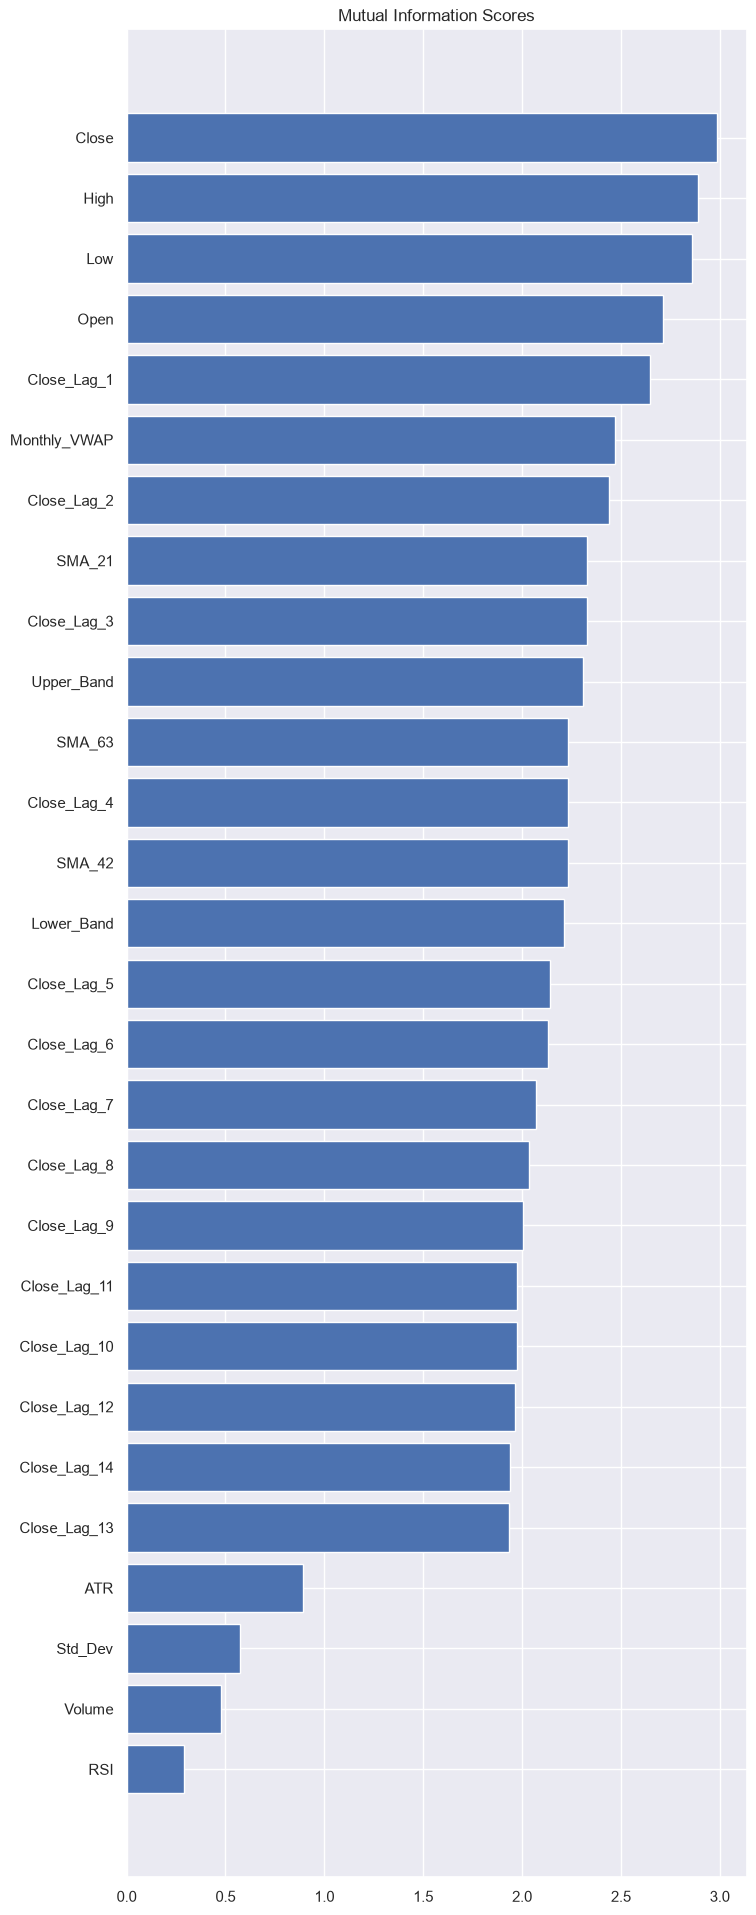

In [478]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


plt.figure(dpi=100, figsize=(8, 24))
plot_mi_scores(mi_scores[mi_scores >= threshold])

Training the Linear Regression model on historical data...
Predicting the last trading year (252 days)...

--- Linear Regressor Report Card ---
Mean Absolute Error (MAE): $7.41
Average Actual Price: $257.62
R-squared (R2 Score): 0.8865


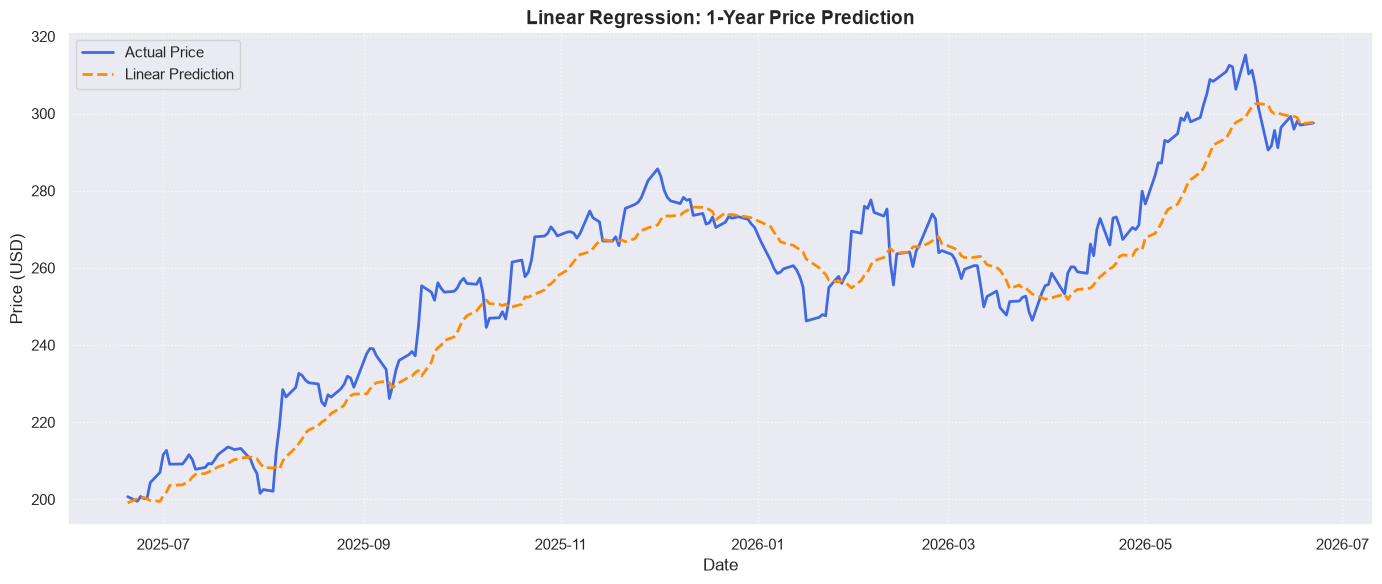

In [479]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# ---------------------------------------------------------
# 1. Initialize and Train 
# ---------------------------------------------------------
# Linear Regression has no "trees" or "depth". It's just pure algebra.
lin_model = LinearRegression()

print("Training the Linear Regression model on historical data...")
lin_model.fit(X_train, y_train)

# ---------------------------------------------------------
# 2. Predict the Out-of-Sample Year
# ---------------------------------------------------------
print("Predicting the last trading year (252 days)...")
lin_preds = lin_model.predict(X_val)

# ---------------------------------------------------------
# 3. Evaluate the Math
# ---------------------------------------------------------
mae = mean_absolute_error(y_val, lin_preds)
r2 = r2_score(y_val, lin_preds)

print("\n--- Linear Regressor Report Card ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Average Actual Price: ${y_val.mean():.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

# ---------------------------------------------------------
# 4. The Visual Reality Check
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))

# Plot the Actual sequence of prices
plt.plot(y_val.index, y_val.values, label='Actual Price', color='royalblue', linewidth=2)

# Plot the Model's predictions over the same timeline
plt.plot(y_val.index, lin_preds, label='Linear Prediction', color='darkorange', linestyle='--', linewidth=2)

plt.title('Linear Regression: 1-Year Price Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()